# Simple RNN

In this notebook, we're going to train a simple RNN to do time-series prediction. Given some set of input data, it should be able to generate a prediction for the next time step!
- create our dataset
- define an RNN in Pytorch
- train our model and see how it performs

![](https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/c9404fc86181fc3f0906b368697268257f348535/recurrent-neural-networks/time-series/assets/time_prediction.png)



In [1]:
import torch
from torch import nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

D:\04_programe\anaconda\envs\torch_gpu\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\04_programe\anaconda\envs\torch_gpu\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\04_programe\anaconda\envs\torch_gpu\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


x.shape:(20, 1), y.shape:(20, 1)


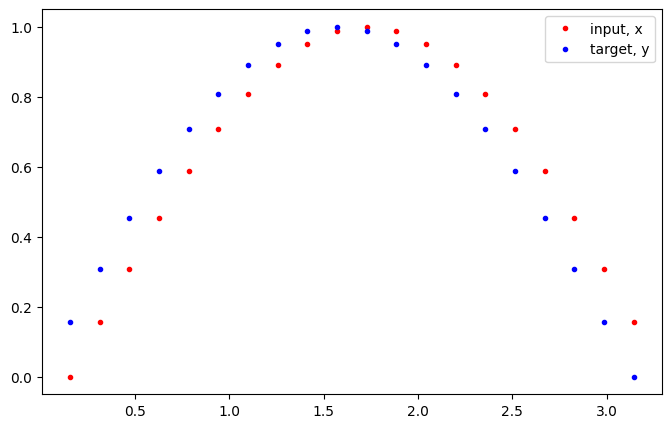

In [7]:
plt.figure(figsize=(8,5))

# how many time steps/data pts are in one batch of data
seq_length = 20

# generate evenly spaced data pts
time_steps = np.linspace(0, np.pi, seq_length + 1)
data = np.sin(time_steps)
data.resize((seq_length + 1, 1)) # size becomes (seq_length+1, 1), adds an input_size dimension

x = data[:-1] # all but the last piece of data
y = data[1:] # all but the first
print(f'x.shape:{x.shape}, y.shape:{y.shape}')
# display the data
plt.plot(time_steps[1:], x, 'r.', label='input, x') # x
plt.plot(time_steps[1:], y, 'b.', label='target, y') # y

plt.legend(loc='best')
plt.show()

## Define RNN
Next, we define an RNN in PyTorch. We'll use `nn.RNN` to create an RNN layer, then we'll add a last, full-connected layer to get the output size that we want. An RNN takes in a number of parameters:
- input_size: the size of the input
- hidden_dim: the number of features in the RNN output and in the hidden state
- n_layers: the number of layers that make up the RNN, typicall 1-3; greater than 1 means that you'll create a stacked RNN
- batch_first: whether or not the input/output of the RNN will have the batch_size as the first dimension (batch_size, seq_length, hidden_dim)

$x_t$ 是当前状态的输入值, $h_{t-1}$ 就是上一个状态的hidden state, 也就是记忆部分. 整个网络要训练的部分就是 $W_{ih}$ 当前状态的输入值权重,

$$
h_t = tanh (W_{ih}x_t + b_{ih} + W_{hh}h_{t-1} + b_{hh})
$$

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义 RNN 类
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size))
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size))
        self.W_hy = nn.Parameter(torch.randn(hidden_size, output_size))
        self.b_h = nn.Parameter(torch.randn(hidden_size))
        self.b_y = nn.Parameter(torch.randn(output_size))
    
    def forward(self, x):
        # 初始化隐藏状态
        h = torch.zeros(1, self.hidden_size)
        
        # 存储每个时间步的输出
        outputs = []
        
        # 遍历输入序列
        for i in range(x.size(0)):
            # 计算隐藏状态
            h = torch.tanh(x[i] @ self.W_xh + h @ self.W_hh + self.b_h)
            
            # 计算输出
            y = h @ self.W_hy + self.b_y
            
            # 保存输出
            outputs.append(y)
        
        # 将输出堆叠成一个张量
        return torch.stack(outputs)

# 超参数
input_size = 10
hidden_size = 20
output_size = 1
seq_length = 5
batch_size = 1

# 创建 RNN 实例
rnn = SimpleRNN(input_size, hidden_size, output_size)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.SGD(rnn.parameters(), lr=0.01)

# 生成随机输入数据和目标数据
x = torch.randn(seq_length, batch_size, input_size)
y = torch.randn(seq_length, batch_size, output_size)

# 训练循环
for epoch in range(100):
    # 前向传播
    outputs = rnn(x)
    
    # 计算损失
    loss = criterion(outputs, y)
    
    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

# 测试模型
with torch.no_grad():
    test_output = rnn(x)
    print("Test Output:", test_output)

Epoch [10/100], Loss: 1.1046
Epoch [20/100], Loss: 0.2367
Epoch [30/100], Loss: 0.0614
Epoch [40/100], Loss: 0.0183
Epoch [50/100], Loss: 0.0059
Epoch [60/100], Loss: 0.0020
Epoch [70/100], Loss: 0.0007
Epoch [80/100], Loss: 0.0002
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0000
tensor([[[-1.8602]],

        [[ 0.0975]],

        [[-1.9239]],

        [[ 1.4166]],

        [[ 0.3726]]])
